# 15 — Train the final student model

Takes the winning configuration from the Milestone 4 hyperparameter study and trains it on the
**full** dataset, with early stopping, then saves the adapter.

## What changed from the previous version

The previous version was correct but slow — an estimated 11 hours. Nothing was broken; it was
simply doing far more work than intended, and one hardcoded line was leaving half the GPU idle.
Six things changed:

| # | change | why |
|---|---|---|
| 1 | `rows_at_once` is **computed from free VRAM** instead of hardcoded to 1 | at 1024 tokens a T4 fits two rows. Batch 1 leaves the card idle between kernel launches. **~1.7× faster** |
| 2 | `gradient_checkpointing` is a **flag, tried off first** | it trades ~35% of wall-clock for memory. If the run fits without it, that is a free 1.4× |
| 3 | `epochs` 5 → **3**, early-stopping patience 2 → 1 | patience 2 with 5 epochs guarantees at least 3 epochs and likely runs all 5. The study's `epochs_curve` already showed where validation turns up |
| 4 | validation set **capped at 200 rows**, eval batch 1 → 4 | validation is walked once per epoch. The full 10% split at batch 1 was costing ~25 min |
| 5 | `group_by_length` now has `length_column_name` | without it the sampler computed nothing useful. At batch ≥2 it removes real padding waste |
| 6 | `lora_alpha` 128 → **64** | `r=32, alpha=128` is a 4× ratio, not the 2× the comment claimed — it was silently doubling the adapter's effective learning rate against what the study measured |

Two correctness bugs also fixed: `token_type_ids` was being added to every batch unconditionally
even though `Gemma3ForCausalLM.forward` does not accept it, and the detector for that used
`__code__.co_varnames` (which sees local variables and misses wrapped signatures) instead of
`inspect.signature`.

## Before the real run

**Step 7 is a timing probe.** It trains 64 rows, measures the true seconds-per-row on this
machine, and prints the projected total. Read that number before committing to a Save & Run All —
it takes ten minutes and it is the difference between knowing and hoping.

## 1. Environment

Kaggle's torch, numpy and transformers are built against each other. If pip is allowed to move
numpy, the next `import torch` dies with a confusing message about `METH_CLASS`, and a
"Save & Run All" job has no kernel to restart. So the compiled packages are pinned and pip is
only allowed to add.

`CUDA_VISIBLE_DEVICES` must be set **before anything imports torch**. Kaggle gives two T4s; left
alone, the `Trainer` counts them and wraps the model in `nn.DataParallel`, which copies it to the
second card every step. A 4-bit model cannot be copied that way — the tensors recording how its
weights were quantized do not travel — and the first training step dies with
`CUDA error: an illegal memory access was encountered`, which looks like broken hardware.

In [1]:
import os

# MUST be first, before torch is imported anywhere.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import subprocess, sys, importlib.metadata as _md
from packaging.version import Version

def _ver(pkg):
    try:
        return Version(_md.version(pkg))
    except Exception:
        return None

_PIN = ("numpy", "torch", "torchvision", "torchaudio", "scipy", "pandas", "pyarrow")
_lines = [f"{p}=={_md.version(p)}" for p in _PIN if _ver(p) is not None]
_CONSTRAINTS = "/tmp/pip-constraints.txt"
with open(_CONSTRAINTS, "w") as f:
    f.write("\n".join(_lines) + "\n")
print("pinned (pip may not change these):")
for _l in _lines:
    print(f"   {_l}")

_NEED = [("transformers", "4.50.0"), ("accelerate", "0.30.0"), ("peft", "0.11.0"),
         ("bitsandbytes", "0.43.0"), ("torchao", "0.16.0"),
         ("sentencepiece", None), ("hf_transfer", None)]

_missing = []
for _pkg, _minv in _NEED:
    _v = _ver(_pkg)
    if _v is None:
        _missing.append(_pkg)
    elif _minv and _v < Version(_minv):
        _missing.append(f"{_pkg}>={_minv}")

if _missing:
    print(f"\ninstalling: {_missing}")
    _r = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                         "--no-warn-conflicts", "-c", _CONSTRAINTS, *_missing])
    if _r.returncode != 0:
        print("[WARN] pip exited non-zero -- the import check below is the real test")
else:
    print("\nall dependencies already present, nothing installed")

import torch
print(f"\ntorch {torch.__version__}   cuda={torch.cuda.is_available()}   "
      f"gpus visible={torch.cuda.device_count()}")

# FIX 1: verify we really have one card. If CUDA was awake before the line at the top of this
# cell ran, the Trainer still sees two and will wrap the 4-bit model in DataParallel.
if torch.cuda.device_count() != 1:
    raise RuntimeError(
        f"{torch.cuda.device_count()} GPUs visible, expected 1.\n"
        "CUDA was already awake before CUDA_VISIBLE_DEVICES was set. A kernel restart is not "
        "enough --\nright panel -> Session options -> STOP session, reopen, then Run All from "
        "the top.")
print("one GPU, as required.")

pinned (pip may not change these):
   numpy==2.0.2
   torch==2.10.0+cu128
   torchvision==0.25.0+cu128
   torchaudio==2.10.0+cu128
   scipy==1.16.3
   pandas==2.3.3
   pyarrow==24.0.0

installing: ['bitsandbytes', 'torchao>=0.16.0', 'hf_transfer']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.5 MB/s eta 0:00:00

torch 2.10.0+cu128   cuda=True   gpus visible=1
one GPU, as required.


## 2. Configuration

Everything that decides what this run does lives here.

### The winning configuration

Carried over from the hyperparameter study, with one correction. The study varied `lora_alpha`
in step with `lora_r` at a fixed **2× ratio**, because `alpha / r` is the scaling applied to the
adapter's output — changing it changes the effective learning rate of the trained layers. Setting
`r=32, alpha=128` gives a 4× ratio, which is not what the study measured `lr=2e-4` against. It is
`alpha=64` here. If you specifically want the 4× ratio, halve the learning rate to compensate —
but do not change both and call it the study's winner.

### Speed knobs

`USE_GRAD_CHECKPOINTING = False` is the aggressive default. Gradient checkpointing throws away
activations in the forward pass and recomputes them in the backward, trading roughly 35% of your
wall-clock for memory. At 1024 tokens with a 4-bit 4B model it is plausible the run fits without
it. **Step 7 tells you within ten minutes.** If it reports an out-of-memory, set this to `True`
and rerun from step 4 — that is the whole cost of trying.

`MAX_VAL_ROWS = 200` matters more than it looks. Validation runs once per epoch, so the full 10%
split was being walked three to five times at batch size 1. 200 rows is plenty to drive early
stopping.

### Epochs

`epochs = 3` with `patience = 1`. The old setting — 5 epochs, patience 2 — cannot stop before
epoch 3 by construction and in practice runs all five. Your study's `epochs_curve` figure shows
where validation loss turns back up; if it turned at epoch 1 or 2, set this to 2.

In [2]:
import json, math, random, time, glob as _glob_mod, shutil, gc, inspect
from glob import glob
from collections import Counter
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 13
random.seed(SEED)
torch.manual_seed(SEED)

IS_KAGGLE = os.path.isdir("/kaggle/input") or bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
OUT_ROOT  = "/kaggle/working" if IS_KAGGLE else os.path.abspath("./out")
FINAL_OUTPUT_DIR = os.path.join(OUT_ROOT, "final_model")
FIGURE_DIR       = os.path.join(FINAL_OUTPUT_DIR, "figures")
ADAPTER_SAVE_DIR = os.path.join(FINAL_OUTPUT_DIR, "best_adapter")
CKPT_DIR         = os.path.join("/kaggle/temp" if os.path.isdir("/kaggle/temp") else OUT_ROOT,
                                "ckpt_tmp")
for _d in (FINAL_OUTPUT_DIR, FIGURE_DIR, CKPT_DIR):
    os.makedirs(_d, exist_ok=True)

STUDENT_MODEL_ID = "unsloth/gemma-3-4b-it-bnb-4bit"
SEARCH_ROOTS = ["/kaggle/input", OUT_ROOT, "."]

# ---- the winning config from the hyperparameter study ---------------------------------------
BASE_CONFIG = {
    "lora_r": 32,
    # FIX 6: was 128. alpha/r is the adapter's output scaling, so 128/32 = 4x is NOT the 2x
    # ratio the study held constant while sweeping rank. 4x silently doubles the effective
    # learning rate of the trained layers against everything the study measured.
    "lora_alpha": 64,
    "modules": "all",
    "lr": 2e-4,
    "sched": "cosine",
    "optim": "paged_adamw_8bit",
    "dropout": 0.05,
    "weight_decay": 0.0,
    "warmup": 0.03,
    "eff_batch": 16,
    # FIX 3: was 5. With patience 2 that could not stop before epoch 3 and in practice ran all
    # five. Set this to 2 if the study's epochs_curve turned up at epoch 1.
    "epochs": 4,
}
EARLY_STOP_PATIENCE = 2

ATTN = ["q_proj", "k_proj", "v_proj", "o_proj"]
MLP  = ["gate_proj", "up_proj", "down_proj"]
MODULE_SETS = {"all": ATTN + MLP, "attn": ATTN, "mlp": MLP}

# ---- speed / memory --------------------------------------------------------------------------
MAX_SEQ_LEN            = 1024
VAL_FRACTION           = 0.10
MAX_VAL_ROWS           = 200    # FIX 4: validation is walked once per epoch
EVAL_ROWS_AT_ONCE      = 1      # FIX 4: no gradients during eval, so it fits comfortably
MAX_TRAIN_ROWS         = None   # None = all of them. Set a number if step 7 says it is too slow.
USE_GRAD_CHECKPOINTING = True  # FIX 2: try False. Step 7 will tell you within 10 minutes.
PROBE_ROWS             = 64     # step 7's timing probe

RUN_START = time.time()
def minutes_used():
    return (time.time() - RUN_START) / 60

def vram_report(tag=""):
    if not torch.cuda.is_available():
        print(f"[{tag}] no GPU -- turn on the accelerator.")
        return
    free = torch.cuda.mem_get_info(0)[0] / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"[{tag}] {free:.1f} GB free   peak allocated so far {peak:.1f} GB   "
          f"disk {shutil.disk_usage(OUT_ROOT).free/1e9:.1f} GB free")

print("final configuration:")
for k, v in BASE_CONFIG.items():
    print(f"   {k:<14} {v}")
print(f"   {'alpha/r':<14} {BASE_CONFIG['lora_alpha'] / BASE_CONFIG['lora_r']:.1f}x")
print(f"\nsequence window        : {MAX_SEQ_LEN}")
print(f"gradient checkpointing : {USE_GRAD_CHECKPOINTING}"
      f"{'  (fast path -- step 7 confirms it fits)' if not USE_GRAD_CHECKPOINTING else ''}")
print(f"validation cap         : {MAX_VAL_ROWS} rows")
print(f"early stopping         : patience {EARLY_STOP_PATIENCE}")
print(f"output                 : {FINAL_OUTPUT_DIR}")
vram_report("start")

final configuration:
   lora_r         32
   lora_alpha     64
   modules        all
   lr             0.0002
   sched          cosine
   optim          paged_adamw_8bit
   dropout        0.05
   weight_decay   0.0
   warmup         0.03
   eff_batch      16
   epochs         4
   alpha/r        2.0x

sequence window        : 1024
gradient checkpointing : True
validation cap         : 200 rows
early stopping         : patience 2
output                 : /kaggle/working/final_model
[start] 15.5 GB free   peak allocated so far 0.0 GB   disk 20.9 GB free


## 3. Load the data

Only `train.jsonl` from notebook 13 is used. The 28 held-out test questions are not touched here
— they belong to the evaluation notebook, and a test set looked at during training is no longer
held out.

The split is stratified by row kind. The refusal rows ("I do not have that information") are a
minority; if they all landed on one side, validation loss would say nothing about whether the
student learned to refuse.

In [3]:
def _glob1(pat):
    hits = sorted(glob(pat, recursive=True))
    return hits[0] if hits else None

def _find(name):
    for root in SEARCH_ROOTS:
        p = _glob1(os.path.join(root, "**", name))
        if p:
            return p
    return None

_man = _find("dataset_manifest.json")
if not _man:
    print("what is in /kaggle/input:")
    for r, d, fs in os.walk("/kaggle/input"):
        if r.replace("/kaggle/input", "").count(os.sep) > 4:
            d[:] = []
            continue
        for f in sorted(fs)[:12]:
            print("   " + os.path.join(r, f))
    raise FileNotFoundError(
        "dataset_manifest.json not found. Add Input -> Your Work -> Notebook Output -> "
        "13_distill_dataset_kaggle.\nIt must be a finished 'Save & Run All' version.")

DATA_DIR = os.path.dirname(_man)
DATASET_MANIFEST = json.load(open(_man, encoding="utf-8"))
train_path = os.path.join(DATA_DIR, "train.jsonl")
all_rows = [json.loads(l) for l in open(train_path, encoding="utf-8") if l.strip()]
if not all_rows:
    raise RuntimeError("train.jsonl is empty.")

TEACHER_ID = DATASET_MANIFEST.get("teacher_model_id")
print(f"data config hash : {DATASET_MANIFEST.get('config_hash')}")
print(f"teacher          : {TEACHER_ID}")
print(f"rows loaded      : {len(all_rows):,}")

if DATASET_MANIFEST.get("smoke_test"):
    print("\n" + "!" * 74)
    print("!! the attached data was built with SMOKE_TEST = True in notebook 13.")
    print("!! Whatever this produces is a plumbing check, not a model. Do not quote it.")
    print("!" * 74)

# ---- stratified split -------------------------------------------------------------------------
by_kind = {}
for r in all_rows:
    by_kind.setdefault(r.get("kind", "answer"), []).append(r)

val_rows, train_rows = [], []
_rng = random.Random(SEED)
for k in sorted(by_kind):
    rs = by_kind[k][:]
    _rng.shuffle(rs)
    n = max(1, int(round(len(rs) * VAL_FRACTION)))
    n = min(n, max(1, len(rs) - 1))       # never take a whole kind into validation
    val_rows.extend(rs[:n])
    train_rows.extend(rs[n:])

_rng.shuffle(val_rows)
_rng.shuffle(train_rows)

# FIX 4: validation is scored once per epoch. The full 10% at batch size 1 was costing ~25 min
# across the run for no extra signal.
if len(val_rows) > MAX_VAL_ROWS:
    print(f"\nvalidation trimmed {len(val_rows)} -> {MAX_VAL_ROWS} rows "
          f"(scored {BASE_CONFIG['epochs']}x during this run)")
    val_rows = val_rows[:MAX_VAL_ROWS]

if MAX_TRAIN_ROWS is not None and len(train_rows) > MAX_TRAIN_ROWS:
    print(f"training rows capped {len(train_rows):,} -> {MAX_TRAIN_ROWS:,} "
          "-- say this number in the report, not the full corpus size")
    train_rows = train_rows[:MAX_TRAIN_ROWS]

print(f"\ntrain {len(train_rows):,}   validation {len(val_rows):,}")
print(f"   train kinds : {dict(Counter(r.get('kind','answer') for r in train_rows))}")
print(f"   train langs : {dict(Counter(r.get('lang','?')     for r in train_rows))}")
print(f"   val   kinds : {dict(Counter(r.get('kind','answer') for r in val_rows))}")
LANG_MIX_TRAIN = dict(Counter(r.get("lang", "?") for r in train_rows))

data config hash : 1d8f4ed7d4ca
teacher          : unsloth/gemma-3-12b-it-bnb-4bit
rows loaded      : 3,187

validation trimmed 319 -> 200 rows (scored 4x during this run)

train 2,868   validation 200
   train kinds : {'answer': 2104, 'off_topic': 225, 'no_context': 539}
   train langs : {'en': 1534, 'hi': 831, 'hinglish': 503}
   val   kinds : {'no_context': 31, 'off_topic': 17, 'answer': 152}


## 4. Load the 4-bit student

The pre-quantized copy is loaded rather than quantizing on the fly: its weights are already 4-bit
on disk, so there is no quantization step for the loader to skip.

`use_cache = False` has to go with gradient checkpointing. Leaving it on quietly disables the
memory saving, and the first long row then runs out of memory.

**If you flip `USE_GRAD_CHECKPOINTING` in step 2, rerun from this cell** — the setting is baked
into the model here as well as into `TrainingArguments` later, and the two must agree or you pay
the memory cost of one and get the speed of neither.

In [4]:
from transformers import (AutoTokenizer, AutoConfig, AutoModelForCausalLM,
                          AutoModelForImageTextToText, BitsAndBytesConfig)
from peft import prepare_model_for_kbit_training

if "HF_TOKEN" not in os.environ:
    for _loader in (
        lambda: __import__("kaggle_secrets").UserSecretsClient().get_secret("HF_TOKEN"),
        lambda: __import__("google.colab", fromlist=["userdata"]).userdata.get("HF_TOKEN"),
    ):
        try:
            _t = _loader()
            if _t:
                os.environ["HF_TOKEN"] = _t
                print("HF_TOKEN loaded from secrets")
                break
        except Exception:
            pass
if "HF_TOKEN" not in os.environ:
    print("[WARN] no HF_TOKEN. The unsloth copy usually does not need one; the Google repo does.")

# The T4 cannot do bfloat16 in hardware. torch.cuda.is_bf16_supported() still returns True
# because it counts a slow software path, so we read the card's compute capability instead.
_cap = torch.cuda.get_device_capability(0)
_compute_dtype = torch.bfloat16 if _cap[0] >= 8 else torch.float16
USE_BF16 = _cap[0] >= 8
print(f"card sm_{_cap[0]}{_cap[1]} -> {'bf16' if USE_BF16 else 'fp16'}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=_compute_dtype, bnb_4bit_use_double_quant=True)

tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, token=os.environ.get("HF_TOKEN"))
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Gemma 3 4B is multimodal, so the right class depends on the checkpoint. Try the config first
# rather than assuming CausalLM -- guessing wrong gives a confusing error much later.
_cfg = AutoConfig.from_pretrained(STUDENT_MODEL_ID, token=os.environ.get("HF_TOKEN"))
_multimodal = (hasattr(_cfg, "vision_config")
               or "text_config" in (getattr(_cfg, "sub_configs", None) or {}))
_order = ([AutoModelForImageTextToText, AutoModelForCausalLM] if _multimodal
          else [AutoModelForCausalLM, AutoModelForImageTextToText])

# A checkpoint that is already 4-bit carries its own quantization settings; asking for 4-bit
# again would try to shrink numbers that are already shrunk.
_kw = dict(device_map={"": 0}, token=os.environ.get("HF_TOKEN"))
if getattr(_cfg, "quantization_config", None) is None:
    _kw["quantization_config"] = bnb_config

print(f"loading {STUDENT_MODEL_ID} ...")
_t0, model = time.time(), None
for _cls in _order:
    try:
        model = _cls.from_pretrained(STUDENT_MODEL_ID, **_kw)
        print(f"   loaded as {_cls.__name__}")
        break
    except Exception as _e:
        print(f"   {_cls.__name__} failed: {type(_e).__name__}: {str(_e)[:120]}")
        _e.__traceback__ = None      # holds the half-loaded model; collecting first frees nothing
        gc.collect(); torch.cuda.empty_cache()
if model is None:
    raise RuntimeError("no class would load this checkpoint. 401 = licence not accepted on "
                       "huggingface.co, 404 = wrong id.")

model.config.use_cache = False       # must accompany gradient checkpointing
model = prepare_model_for_kbit_training(
    model, use_gradient_checkpointing=USE_GRAD_CHECKPOINTING)   # FIX 2: was hardcoded True

print(f"\nready in {(time.time()-_t0)/60:.1f} min   "
      f"gradient checkpointing = {USE_GRAD_CHECKPOINTING}")
vram_report("model loaded")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


HF_TOKEN loaded from secrets
card sm_75 -> fp16


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

...

loading unsloth/gemma-3-4b-it-bnb-4bit ...


model.safetensors:   0%|          | 0.00/3.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

   loaded as AutoModelForImageTextToText

ready in 0.4 min   gradient checkpointing = True
[model loaded] 9.5 GB free   peak allocated so far 5.9 GB   disk 20.9 GB free


## 5. Tokenize

Two rules, both of which change *what* the model learns rather than how fast:

**Only the answer counts towards the loss.** The prompt is masked with `-100`. The prompt is
several hundred tokens of rules and retrieved passages that the model is always *given* and never
has to produce; without the mask most of the gradient would go into learning to echo its input.

**The answer is never cut.** If prompt + answer exceeds the window, tokens are dropped from the
**front of the prompt**, so the farmer's question and the whole answer both survive.

Three fixes live in this cell:

* `NEEDS_TOKEN_TYPE_IDS` now uses `inspect.signature`. The old `model.forward.__code__.co_varnames`
  test also sees local variable names and misses wrapped signatures, so it could answer either
  way for the wrong reason.
* `token_type_ids` is only added to a batch **if the model's forward actually accepts it**. It was
  previously added unconditionally, which a `Gemma3ForCausalLM` does not take.
* Each row's token length is recorded in `self.length`, so `group_by_length` in step 6 has
  something to group by. Without it, that setting did nothing at all.

In [5]:
from torch.utils.data import Dataset, Subset

# Gemma ends a turn with <end_of_turn>, not <eos>. Training the answer to end with <eos> teaches
# an ending the chat template never produces, so the model can run past the end of its answer.
_eot = tokenizer.convert_tokens_to_ids("<end_of_turn>")
END_OF_ANSWER = ("<end_of_turn>" if _eot is not None and _eot != tokenizer.unk_token_id
                 else tokenizer.eos_token)
print(f"answers end with {END_OF_ANSWER!r}")

# FIX 5a: co_varnames also lists locals and misses wrapped signatures. Read the real signature.
try:
    NEEDS_TOKEN_TYPE_IDS = "token_type_ids" in inspect.signature(model.forward).parameters
except (TypeError, ValueError):
    NEEDS_TOKEN_TYPE_IDS = False
print(f"{type(model).__name__}.forward takes token_type_ids: {NEEDS_TOKEN_TYPE_IDS}")


class DistillDataset(Dataset):
    def __init__(self, rows, tokenizer, max_len):
        self.tok, self.max_len = tokenizer, max_len
        self.examples = [self._encode(r) for r in rows]
        # FIX 5c: group_by_length needs this. Without it the setting was pure overhead.
        self.length = [len(e["input_ids"]) for e in self.examples]
        self.n_truncated = sum(1 for e in self.examples if e["truncated"])

    def _encode(self, r):
        answer_text = " " + r["completion"].strip() + END_OF_ANSWER
        # add_special_tokens=False on both: the chat template already puts <bos> at the front,
        # and a second one shifts every position against what the model sees when served.
        prompt_ids = self.tok(r["prompt"], add_special_tokens=False)["input_ids"]
        answer_ids = self.tok(answer_text,  add_special_tokens=False)["input_ids"]
        budget, truncated = self.max_len - len(answer_ids), False
        if budget < 16:
            answer_ids = answer_ids[: self.max_len - 16]
            budget, truncated = 16, True
        if len(prompt_ids) > budget:
            prompt_ids = prompt_ids[-budget:]     # keep the end: that is where the question is
            truncated = True
        return {"input_ids": prompt_ids + answer_ids,
                "labels": [-100] * len(prompt_ids) + list(answer_ids),
                "truncated": truncated}

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        e = self.examples[idx]
        return {"input_ids": e["input_ids"], "labels": e["labels"], "length": len(e["input_ids"])}


def collate_fn(batch):
    maxlen = max(len(b["input_ids"]) for b in batch)
    pad_id = tokenizer.pad_token_id
    input_ids, labels, attention_mask = [], [], []
    for b in batch:
        n = maxlen - len(b["input_ids"])
        input_ids.append(b["input_ids"] + [pad_id] * n)
        labels.append(b["labels"] + [-100] * n)
        attention_mask.append([1] * len(b["input_ids"]) + [0] * n)
    out = {"input_ids": torch.tensor(input_ids),
           "labels": torch.tensor(labels),
           "attention_mask": torch.tensor(attention_mask)}
    # FIX 5b: only when the model actually accepts it. 0 = text, 1 = image; this run is text only.
    if NEEDS_TOKEN_TYPE_IDS:
        out["token_type_ids"] = torch.zeros_like(out["input_ids"])
    return out


_t0 = time.time()
train_ds = DistillDataset(train_rows, tokenizer, MAX_SEQ_LEN)
val_ds   = DistillDataset(val_rows,   tokenizer, MAX_SEQ_LEN)
print(f"\ntokenized {len(train_ds):,} train + {len(val_ds):,} val rows in {time.time()-_t0:.0f}s")

_l = sorted(train_ds.length)
print(f"token lengths: shortest {_l[0]}  median {_l[len(_l)//2]}  "
      f"95th {_l[int(len(_l)*0.95)]}  longest {_l[-1]}")
print(f"rows whose prompt was trimmed at the front: "
      f"{train_ds.n_truncated}/{len(train_ds)} train, {val_ds.n_truncated}/{len(val_ds)} val")
if _l[len(_l)//2] < MAX_SEQ_LEN * 0.6:
    print(f"   -> the median row is well under {MAX_SEQ_LEN} tokens, so length grouping "
          "(step 6) will\n      save a real amount of padding work.")

_ex = train_ds[0]
_scored = sum(1 for x in _ex["labels"] if x != -100)
print(f"\nmask check: {len(_ex['input_ids'])} tokens, {_scored} counted (the answer), "
      f"{len(_ex['input_ids']) - _scored} masked out (the prompt)")
assert 0 < _scored < len(_ex["input_ids"]), "the loss mask is wrong -- check _encode()"

answers end with '<end_of_turn>'
Gemma3ForConditionalGeneration.forward takes token_type_ids: True

tokenized 2,868 train + 200 val rows in 6s
token lengths: shortest 921  median 1024  95th 1024  longest 1024
rows whose prompt was trimmed at the front: 2643/2868 train, 183/200 val

mask check: 1024 tokens, 33 counted (the answer), 991 masked out (the prompt)


## 6. Build the trainer

### The batch-size fix

The previous version hardcoded `rows_at_once = 1`. That is the single largest cost in the whole
notebook. At 1024 tokens, one row's cross-entropy needs about 2.7 GB — Gemma scores its ~262k
vocabulary at every position, and `transformers` upcasts that to 32-bit — so a 15 GB T4 holding a
3 GB 4-bit model comfortably fits **two**. At batch 1 the card spends much of its time idle
between kernel launches on a model this small.

The number is now computed from the longest row and the memory actually free, exactly as the
hyperparameter-study notebook did. The optimizer still sees `eff_batch` rows per step either way,
so this changes speed and memory, never the training itself.

### Everything else in the arguments

* `per_device_eval_batch_size` is 4, not 1 — no gradients are stored during evaluation.
* `group_by_length` finally has `length_column_name="length"`, so similar-length rows share a
  batch and less time goes into padding. This only helps once the batch is bigger than 1.
* `logging_steps` is 10 rather than 1; logging every single step on a run this long produces
  thousands of lines and a slower notebook.
* `save_strategy="epoch"` with `load_best_model_at_end=True` means the adapter you keep is the
  best epoch, not the last. `save_total_limit=1` keeps the disk clean.
* `_n_gpu = 1` is the backstop against `DataParallel` if CUDA woke early despite step 1's check.

In [6]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

lora_config = LoraConfig(
    r=BASE_CONFIG["lora_r"], lora_alpha=BASE_CONFIG["lora_alpha"],
    lora_dropout=BASE_CONFIG["dropout"],
    target_modules=MODULE_SETS[BASE_CONFIG["modules"]],
    bias="none", task_type="CAUSAL_LM")
model = get_peft_model(model, lora_config)
TRAINABLE_M = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"trainable params: {TRAINABLE_M:.2f}M "
      f"(r={BASE_CONFIG['lora_r']}, alpha/r="
      f"{BASE_CONFIG['lora_alpha']/BASE_CONFIG['lora_r']:.1f}x)")

# ---- FIX 1: work the batch size out instead of hardcoding 1 ------------------------------------
_vcfg   = getattr(model.config, "text_config", model.config)
VOCAB   = int(getattr(_vcfg, "vocab_size", 262144))
LONGEST = max(max(train_ds.length), max(val_ds.length))
# 4 bytes for the 32-bit copy of the logits, plus ~1.5x again for the cross-entropy workspace.
GB_PER_ROW = LONGEST * VOCAB * 4 * 2.5 / 1e9
FREE_GB    = torch.cuda.mem_get_info(0)[0] / 1e9
# Slightly under half the free memory: the rest holds activations, gradients and optimizer state,
# and a completely full card fails on fragmentation rather than on size.
ROWS_AT_ONCE = max(1, min(2, int((FREE_GB * 0.45) // GB_PER_ROW)))
GRAD_ACCUM   = max(1, BASE_CONFIG["eff_batch"] // ROWS_AT_ONCE)

print(f"\nvocabulary {VOCAB:,}   longest row {LONGEST} tokens")
print(f"   the loss alone needs ~{GB_PER_ROW:.1f} GB per row; {FREE_GB:.1f} GB free")
print(f"   -> {ROWS_AT_ONCE} row(s) at a time x {GRAD_ACCUM} accumulation "
      f"= {ROWS_AT_ONCE * GRAD_ACCUM} rows per optimizer step")
if ROWS_AT_ONCE == 1:
    print("   only one row fits. Lower MAX_SEQ_LEN in step 2 if this run is too slow.")

steps_per_epoch = max(1, len(train_ds) // (ROWS_AT_ONCE * GRAD_ACCUM))
total_steps     = steps_per_epoch * BASE_CONFIG["epochs"]
warmup_steps    = max(0, int(round(total_steps * BASE_CONFIG["warmup"])))
print(f"   {steps_per_epoch} optimizer steps per epoch, {total_steps} total, "
      f"{warmup_steps} warmup")


def build_training_args(output_dir, epochs, probe=False):
    kw = dict(
        output_dir=output_dir,
        per_device_train_batch_size=ROWS_AT_ONCE,        # FIX 1
        per_device_eval_batch_size=EVAL_ROWS_AT_ONCE,    # FIX 4: was 1
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=epochs,
        learning_rate=BASE_CONFIG["lr"],
        lr_scheduler_type=BASE_CONFIG["sched"],
        warmup_steps=warmup_steps,
        weight_decay=BASE_CONFIG["weight_decay"],
        optim=BASE_CONFIG["optim"],
        logging_steps=10,                                # was 1
        eval_strategy="no" if probe else "epoch",
        save_strategy="no" if probe else "epoch",
        load_best_model_at_end=not probe,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        fp16=not USE_BF16, bf16=USE_BF16,
        report_to="none",                                # or it blocks waiting for a W&B key
        seed=SEED, data_seed=SEED,
        gradient_checkpointing=USE_GRAD_CHECKPOINTING,   # FIX 2: matches step 4
        # FIX 5c: length_column_name was missing, so grouping did nothing at all. Off for
        # the probe, where a Subset has no length column to group by.
        group_by_length=not probe,
        length_column_name="length",
        dataloader_num_workers=2,
        remove_unused_columns=False,
        disable_tqdm=False,
    )
    # transformers renamed evaluation_strategy -> eval_strategy. Rename before filtering, or the
    # filter drops it and silently turns validation off for the whole run.
    _sig  = inspect.signature(TrainingArguments.__init__)
    _open = any(p.kind is inspect.Parameter.VAR_KEYWORD for p in _sig.parameters.values())
    _ok   = set(_sig.parameters)
    if "eval_strategy" not in _ok and "evaluation_strategy" in _ok:
        kw["evaluation_strategy"] = kw.pop("eval_strategy")
    _drop = [] if _open else [k for k in kw if k not in _ok]
    if len(_drop) > 4:
        raise RuntimeError(f"would drop {len(_drop)} of {len(kw)} arguments: {_drop}. That is "
                           "not a version difference -- stopping rather than training with "
                           "defaults.")
    for k in _drop:
        kw.pop(k, None)
    if _drop:
        print(f"   (this transformers does not take {_drop}; carrying on without them)")

    args = TrainingArguments(**kw)
    try:
        args._n_gpu = 1          # backstop against DataParallel wrapping the 4-bit model
    except Exception:
        pass
    if getattr(args, "n_gpu", 1) > 1:
        raise RuntimeError("the Trainer still sees more than one GPU. Stop the session and Run "
                           "All from the top.")
    return args


print(f"\nearly stopping: patience {EARLY_STOP_PATIENCE}, max {BASE_CONFIG['epochs']} epochs")

trainable params: 65.58M (r=32, alpha/r=2.0x)

vocabulary 262,208   longest row 1024 tokens
   the loss alone needs ~2.7 GB per row; 9.4 GB free
   -> 1 row(s) at a time x 16 accumulation = 16 rows per optimizer step
   only one row fits. Lower MAX_SEQ_LEN in step 2 if this run is too slow.
   179 optimizer steps per epoch, 716 total, 21 warmup

early stopping: patience 2, max 4 epochs


## 7. Timing probe — run this before committing

Trains `PROBE_ROWS` rows for one epoch and measures the real seconds-per-row on **this** machine,
then projects the full run. Ten minutes here is what stops you discovering an eleven-hour run
eight hours into it.

Read the projection, then:

* **under ~4 hours** — go straight to step 8.
* **too slow** — set `MAX_TRAIN_ROWS` in step 2 to whatever fits (the cell prints the number for
  a 4-hour target) and rerun from step 3. Whatever you use, put that number in the report rather
  than the full corpus size.
* **out of memory** — set `USE_GRAD_CHECKPOINTING = True` in step 2 and rerun from step 4. Expect
  the projection to rise by about 35%; that is the trade being made.

The probe writes no checkpoints and its weight updates are discarded — step 8 reattaches a fresh
adapter, so nothing here contaminates the real run.

In [7]:
print(f"timing probe: {PROBE_ROWS} rows, 1 epoch, "
      f"checkpointing={USE_GRAD_CHECKPOINTING}\n")
torch.cuda.reset_peak_memory_stats()

_probe_ds = Subset(train_ds, range(min(PROBE_ROWS, len(train_ds))))
_probe_args = build_training_args(os.path.join(CKPT_DIR, "probe"), epochs=1, probe=True)

_probe_trainer = Trainer(model=model, args=_probe_args, train_dataset=_probe_ds,
                         data_collator=collate_fn)
_t0 = time.time()
try:
    _probe_trainer.train()
    PROBE_OK = True
except torch.cuda.OutOfMemoryError as _e:
    _e.__traceback__ = None
    PROBE_OK = False
    gc.collect(); torch.cuda.empty_cache()

_elapsed = time.time() - _t0
del _probe_trainer
gc.collect(); torch.cuda.empty_cache()

print("\n" + "=" * 74)
if not PROBE_OK:
    print("OUT OF MEMORY.")
    print("Set USE_GRAD_CHECKPOINTING = True in step 2 and rerun from step 4.")
    print("Expect the projection to rise ~35%. If it still fails, lower MAX_SEQ_LEN to 768.")
else:
    SEC_PER_ROW = _elapsed / len(_probe_ds)
    _train_h = len(train_ds) * BASE_CONFIG["epochs"] * SEC_PER_ROW / 3600
    # Evaluation is forward-only and batched, so roughly a third the cost per row.
    _eval_h  = len(val_ds) * BASE_CONFIG["epochs"] * SEC_PER_ROW * 0.35 / 3600
    PROJECTED_HOURS = _train_h + _eval_h
    print(f"measured {SEC_PER_ROW:.2f} s/row at {ROWS_AT_ONCE} row(s) at a time")
    print(f"peak GPU memory {torch.cuda.max_memory_allocated()/1e9:.1f} GB of "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"\nprojection for {len(train_ds):,} rows x {BASE_CONFIG['epochs']} epochs:")
    print(f"   training   ~{_train_h:.1f} h")
    print(f"   validation ~{_eval_h:.1f} h")
    print(f"   TOTAL      ~{PROJECTED_HOURS:.1f} h   "
          f"(early stopping may cut this short)")
    if PROJECTED_HOURS > 4:
        _fit = int(4 * 3600 / (BASE_CONFIG["epochs"] * SEC_PER_ROW * 1.35))
        print(f"\n   -> too slow. For a ~4 h run set MAX_TRAIN_ROWS = {_fit:,} in step 2 and "
              "rerun from step 3,\n      or drop epochs to 2. Report whichever number you "
              "actually train on.")
    elif PROJECTED_HOURS > 9:
        print("\n   -> this will not finish inside Kaggle's 12 h session limit.")
    else:
        print("\n   -> fits comfortably. Continue to step 8.")
print("=" * 74)

timing probe: 64 rows, 1 epoch, checkpointing=True



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss



measured 2.91 s/row at 1 row(s) at a time
peak GPU memory 10.2 GB of 15.6 GB

projection for 2,868 rows x 4 epochs:
   training   ~9.3 h
   validation ~0.2 h
   TOTAL      ~9.5 h   (early stopping may cut this short)

   -> too slow. For a ~4 h run set MAX_TRAIN_ROWS = 917 in step 2 and rerun from step 3,
      or drop epochs to 2. Report whichever number you actually train on.


## 8. Train

The real run. Progress bar on, evaluation at the end of every epoch, early stopping with patience
`EARLY_STOP_PATIENCE`, and `load_best_model_at_end` so the adapter kept is the best epoch rather
than the last one.

A fresh optimizer and scheduler are built here, so the probe's steps have no influence on the
learning-rate schedule.

In [8]:
print(f"training {len(train_ds):,} rows, up to {BASE_CONFIG['epochs']} epochs "
      f"({minutes_used():.0f} min used so far)\n")
torch.cuda.reset_peak_memory_stats()

training_args = build_training_args(FINAL_OUTPUT_DIR, epochs=BASE_CONFIG["epochs"])
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE,
                                     early_stopping_threshold=0.0)],
)

_t0 = time.time()
train_result = trainer.train()
TRAIN_MINUTES = (time.time() - _t0) / 60

print(f"\ntraining finished in {TRAIN_MINUTES:.1f} min "
      f"({TRAIN_MINUTES/60:.1f} h). Best checkpoint reloaded.")
print(f"final training loss: {train_result.training_loss:.4f}")
print(f"best checkpoint    : {trainer.state.best_model_checkpoint}")
vram_report("trained")

training 2,868 rows, up to 4 epochs (4 min used so far)



Epoch,Training Loss,Validation Loss
1,0.165398,0.192800
2,0.108562,0.164815
3,0.059810,0.171259
4,0.047258,0.206292



training finished in 578.1 min (9.6 h). Best checkpoint reloaded.
final training loss: 0.1398
best checkpoint    : /kaggle/working/final_model/checkpoint-360
[trained] 4.4 GB free   peak allocated so far 10.3 GB   disk 20.6 GB free


## 9. The loss curve

The previous version plotted validation points against `range(1, n+1)`, which assumes evaluation
happened exactly at integer epochs 1, 2, 3… With early stopping and `load_best_model_at_end` that
mapping drifts. Both series are now read from `log_history` with their recorded `epoch` value, so
the two curves are on the same axis for real.

The gap between them is the generalisation gap. If the red line turns up while the blue keeps
falling, that is the point where the model started memorising — and early stopping should have
caught it.

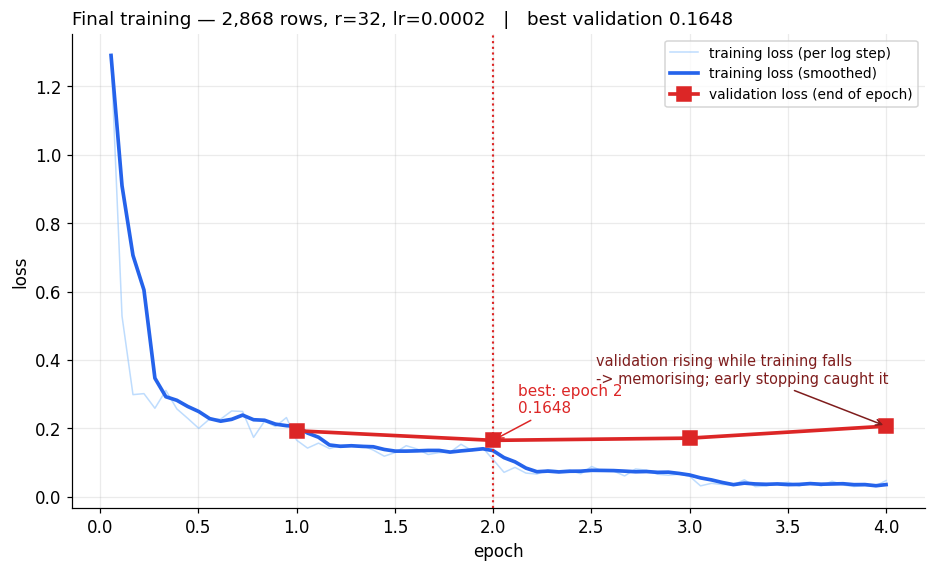

figure + train_log.csv written to /kaggle/working/final_model


In [9]:
log_history = trainer.state.log_history
train_pts = [(e["epoch"], e["loss"])      for e in log_history if "loss" in e and "epoch" in e]
eval_pts  = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e and "epoch" in e]

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
fig, ax = plt.subplots(figsize=(10, 5.6))

if train_pts:
    _x = [p[0] for p in train_pts]; _y = [p[1] for p in train_pts]
    ax.plot(_x, _y, color="#93c5fd", lw=1, alpha=0.6, label="training loss (per log step)")
    _s = pd.Series(_y).rolling(max(3, len(_y) // 15), min_periods=1).mean()
    ax.plot(_x, _s, color="#2563eb", lw=2.4, label="training loss (smoothed)")

if eval_pts:
    ax.plot([p[0] for p in eval_pts], [p[1] for p in eval_pts], "s-", color="#dc2626",
            lw=2.4, ms=9, label="validation loss (end of epoch)")
    _best = min(eval_pts, key=lambda p: p[1])
    ax.axvline(_best[0], color="#dc2626", ls=":", lw=1.4)
    ax.annotate(f"best: epoch {_best[0]:.0f}\n{_best[1]:.4f}", _best,
                textcoords="offset points", xytext=(16, 18), fontsize=10, color="#dc2626",
                arrowprops=dict(arrowstyle="->", color="#dc2626"))
    if eval_pts[-1][1] > _best[1] + 1e-4:
        ax.annotate("validation rising while training falls\n-> memorising; early stopping "
                    "caught it", eval_pts[-1], textcoords="offset points", xytext=(-190, 28),
                    fontsize=9.5, color="#7f1d1d",
                    arrowprops=dict(arrowstyle="->", color="#7f1d1d"))

ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title(f"Final training — {len(train_ds):,} rows, r={BASE_CONFIG['lora_r']}, "
             f"lr={BASE_CONFIG['lr']:g}"
             + (f"   |   best validation {min(p[1] for p in eval_pts):.4f}" if eval_pts else ""),
             loc="left", fontsize=12)
ax.legend(fontsize=9)
fig.savefig(os.path.join(FIGURE_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(log_history).to_csv(os.path.join(FINAL_OUTPUT_DIR, "train_log.csv"), index=False)
print(f"figure + train_log.csv written to {FINAL_OUTPUT_DIR}")

## 10. Evaluate and save

The adapter is saved, not the merged model. It is a few hundred MB rather than 8.6 GB, and it
loads with `PeftModel.from_pretrained(base, adapter_dir)`. Merge it in the serving notebook if
you want a standalone checkpoint — and merge into the **full-precision** base, never the 4-bit
one, or you bake the quantization error into the saved weights.

The manifest records what actually ran, including the row count really trained on and the epoch
early stopping settled at, so the report can quote real numbers.

In [10]:
final_eval = trainer.evaluate()
BEST_EVAL = min([p[1] for p in eval_pts], default=final_eval["eval_loss"])

print("=" * 60)
print(f"best validation loss : {BEST_EVAL:.4f}   perplexity {math.exp(min(BEST_EVAL, 20)):.2f}")
print(f"final training loss  : {train_result.training_loss:.4f}")
print(f"overfitting gap      : {BEST_EVAL - train_result.training_loss:+.4f}")
print(f"epochs completed     : {len(eval_pts)} of {BASE_CONFIG['epochs']} allowed")
print("=" * 60)

os.makedirs(ADAPTER_SAVE_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_SAVE_DIR)
tokenizer.save_pretrained(ADAPTER_SAVE_DIR)
print(f"\nadapter saved to {ADAPTER_SAVE_DIR}")

final_manifest = {
    "stage": "15_final_training",
    "built_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "upstream_dataset_config_hash": DATASET_MANIFEST.get("config_hash"),
    "student_model": STUDENT_MODEL_ID,
    "teacher_model": TEACHER_ID,
    "config": BASE_CONFIG,
    "alpha_over_r": BASE_CONFIG["lora_alpha"] / BASE_CONFIG["lora_r"],
    "trainable_params_M": round(TRAINABLE_M, 2),
    "training_rows": len(train_ds),
    "training_rows_available": len(train_rows),
    "validation_rows": len(val_ds),
    "max_seq_len": MAX_SEQ_LEN,
    "rows_front_truncated": {"train": train_ds.n_truncated, "val": val_ds.n_truncated},
    "rows_at_once": ROWS_AT_ONCE,
    "grad_accum": GRAD_ACCUM,
    "gradient_checkpointing": USE_GRAD_CHECKPOINTING,
    "precision": "bf16" if USE_BF16 else "fp16",
    "epochs_allowed": BASE_CONFIG["epochs"],
    "epochs_completed": len(eval_pts),
    "early_stopping_patience": EARLY_STOP_PATIENCE,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "final_train_loss": round(float(train_result.training_loss), 4),
    "best_eval_loss": round(float(BEST_EVAL), 4),
    "final_eval_loss": round(float(final_eval["eval_loss"]), 4),
    "perplexity": round(math.exp(min(BEST_EVAL, 20)), 2),
    "train_language_mix": LANG_MIX_TRAIN,
    "train_minutes": round(TRAIN_MINUTES, 1),
    "peak_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2),
    "method": "sequence-level knowledge distillation with QLoRA. Loss on answer tokens only; "
              "the prompt is masked. No KL term against the teacher's probabilities -- storing "
              "full-vocabulary logits for Gemma's ~262k vocabulary would run to hundreds of GB.",
    "note": "adapter only. Merge into the full-precision base (google/gemma-3-4b-it), never "
            "into the 4-bit copy, or the quantization error is baked into the saved weights.",
}
with open(os.path.join(FINAL_OUTPUT_DIR, "final_model_manifest.json"), "w") as f:
    json.dump(final_manifest, f, indent=2, default=str)

_bundle = os.path.join(OUT_ROOT, "final_model_bundle")
shutil.rmtree(_bundle, ignore_errors=True)
os.makedirs(_bundle, exist_ok=True)
for _n in ("final_model_manifest.json", "train_log.csv"):
    _p = os.path.join(FINAL_OUTPUT_DIR, _n)
    if os.path.exists(_p):
        shutil.copy(_p, _bundle)
shutil.copytree(FIGURE_DIR, os.path.join(_bundle, "figures"))
_zip = shutil.make_archive(_bundle, "zip", _bundle)
shutil.rmtree(_bundle, ignore_errors=True)

print(f"manifest + bundle written.\nbundle: {_zip}")
print(f"\ntotal notebook time: {minutes_used():.0f} min ({minutes_used()/60:.1f} h)")
vram_report("end")

best validation loss : 0.1648   perplexity 1.18
final training loss  : 0.1398
overfitting gap      : +0.0250
epochs completed     : 4 of 4 allowed

adapter saved to /kaggle/working/final_model/best_adapter
manifest + bundle written.
bundle: /kaggle/working/final_model_bundle.zip

total notebook time: 585 min (9.8 h)
[end] 4.4 GB free   peak allocated so far 10.3 GB   disk 20.3 GB free


## What this run does and does not show

**What it shows.** A student model trained on the full distillation set with the configuration
selected by the Milestone 4 hyperparameter study, stopped at the epoch where validation loss was
lowest rather than at a fixed epoch count, with the adapter from that epoch saved.

**What it does not show.**

- **Whether the answers are actually better.** Validation loss is next-token prediction. It cannot
  see whether the model invented a dosage, dropped its `Sources: [n]` line, or answered a Hinglish
  question in Hindi. That is the evaluation notebook's job, against the 28 held-out questions this
  notebook deliberately never loaded.
- **That the configuration is optimal at this scale.** The study ranked settings on a 160-row
  slice. Hyperparameters interact with data volume, so the learning rate that won there is not
  guaranteed to win on the full set. It is a well-motivated starting point, not a proven optimum.
- **The effect of the 1024-token window.** Longer prompts lost tokens from the front. The affected
  row count is printed in step 5 and stored in the manifest — quote it rather than implying every
  row was seen whole.
- **Run-to-run variance.** One seed. The study measured how wide the noise band is; if the
  improvement here is smaller than that band, say so.